# Learning AR(p) with Recurrent Neural Networks

We compare three RNN architectures — **Simple RNN**, **LSTM**, and **GRU** — on the task of learning a linear AR(5) process.

Each model receives a sequence of $P$ past values $[Y_{t-P}, \ldots, Y_{t-1}]$ and predicts $Y_t$.

Results are compared against the OLS baseline from `ols_estimation.ipynb`.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from AR_specs import P, SIGMA

### Load data and true alphas

In [2]:
ar_data = pd.read_csv('saved_data/ar_data.csv', index_col='t')
Y_full = ar_data['Y'].to_numpy()

alpha_df = pd.read_csv('saved_data/alphas.csv', index_col='lags')
true_alphas = alpha_df['alpha'].to_numpy()

print(f'Loaded {len(Y_full)} data points, AR order P={P}')
print(f'True alphas: {true_alphas}')

Loaded 100001 data points, AR order P=5
True alphas: [-0.44775626  0.78521643 -0.21437406 -0.48722836  0.23731253]


### Build sequences and split into train/test

In [3]:
def build_sequences(Y, p):
    """Return (X, y) where X[i] has shape (p, 1) and y[i] is a scalar target."""
    n = len(Y) - p
    X = np.zeros((n, p, 1))
    y = np.zeros(n)
    for i in range(n):
        X[i, :, 0] = Y[i : i + p]
        y[i] = Y[i + p]
    return X, y

X_all, y_all = build_sequences(Y_full, P)

split = int(len(y_all) * 0.8)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True
)

print(f'Train sequences: {X_train_t.shape}')
print(f'Test sequences:  {X_test_t.shape}')

Train sequences: torch.Size([79996, 5, 1])
Test sequences:  torch.Size([20000, 5, 1])


In [4]:
device = torch.device(
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Model definition

A single recurrent layer (parameterized by type) followed by a linear head.

In [5]:
class ARNet(nn.Module):
    def __init__(self, rnn_type='RNN', input_size=1, hidden_size=10, num_layers=1):
        super().__init__()
        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)
        self.rnn_type = rnn_type

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

### Training loop

Train all three models with identical hyperparameters.

In [ ]:
def train_model(rnn_type, train_loader, device, hidden_size=10, lr=1e-3, epochs=30):
    model = ARNet(rnn_type=rnn_type, hidden_size=hidden_size).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_samples = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)f
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        avg_loss = epoch_loss / n_samples
        losses.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  [{rnn_type}] epoch {epoch+1:3d}/{epochs}: loss = {avg_loss:.6f}')

    return model, losses

In [7]:
rnn_types = ['RNN', 'LSTM', 'GRU']
models = {}
all_losses = {}

for rnn_type in rnn_types:
    print(f'\nTraining {rnn_type}...')
    model, losses = train_model(rnn_type, train_loader, device)
    models[rnn_type] = model
    all_losses[rnn_type] = losses


Training RNN...
  [RNN] epoch   1/30: loss = 9.803777
  [RNN] epoch  10/30: loss = 1.122666
  [RNN] epoch  20/30: loss = 1.029960
  [RNN] epoch  30/30: loss = 1.017059

Training LSTM...
  [LSTM] epoch   1/30: loss = 12.008790
  [LSTM] epoch  10/30: loss = 1.249148
  [LSTM] epoch  20/30: loss = 1.049902
  [LSTM] epoch  30/30: loss = 1.026015

Training GRU...
  [GRU] epoch   1/30: loss = 10.746013
  [GRU] epoch  10/30: loss = 1.090451
  [GRU] epoch  20/30: loss = 1.024255
  [GRU] epoch  30/30: loss = 1.016600


### Training loss curves

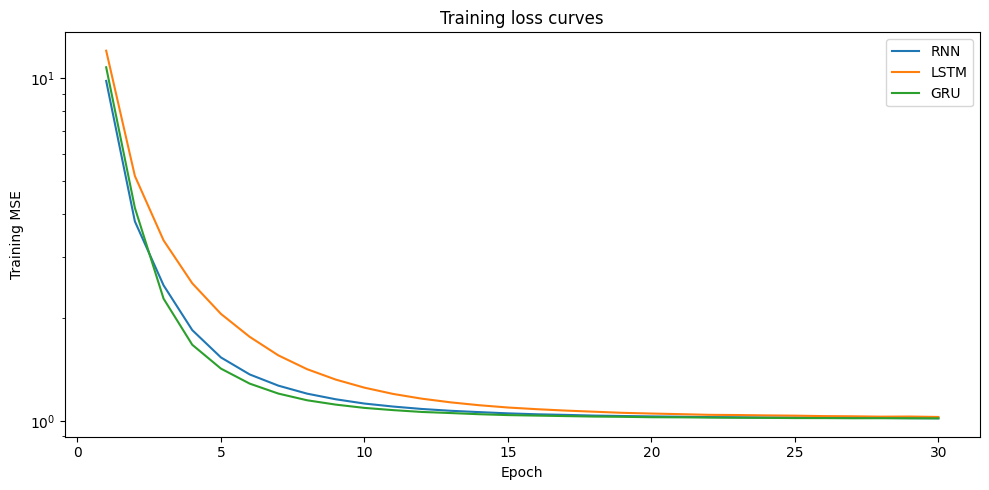

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for rnn_type, losses in all_losses.items():
    ax.plot(range(1, len(losses) + 1), losses, label=rnn_type)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training MSE')
ax.set_title('Training loss curves')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Test set predictions

In [9]:
test_preds = {}
test_mses = {}

for rnn_type, model in models.items():
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t.to(device)).cpu().numpy()
    test_preds[rnn_type] = preds
    mse = float(np.mean((preds - y_test) ** 2))
    test_mses[rnn_type] = mse
    print(f'{rnn_type} test MSE: {mse:.6f}')

RNN test MSE: 1.021868
LSTM test MSE: 1.039439
GRU test MSE: 1.017513


### Comparison with OLS

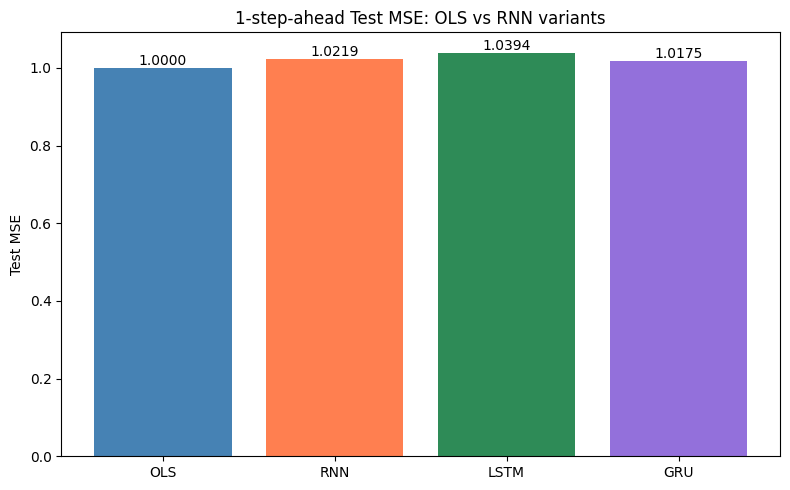

In [10]:
ols_mse_df = pd.read_csv('saved_data/ols_mse.csv')
ols_mse = ols_mse_df['test_mse'].iloc[0]

all_mses = {'OLS': ols_mse}
all_mses.update(test_mses)

fig, ax = plt.subplots(figsize=(8, 5))
methods = list(all_mses.keys())
mse_vals = list(all_mses.values())
bars = ax.bar(methods, mse_vals, color=['steelblue', 'coral', 'seagreen', 'mediumpurple'])
ax.set_ylabel('Test MSE')
ax.set_title('1-step-ahead Test MSE: OLS vs RNN variants')
for bar, val in zip(bars, mse_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### Time series overlay on test data

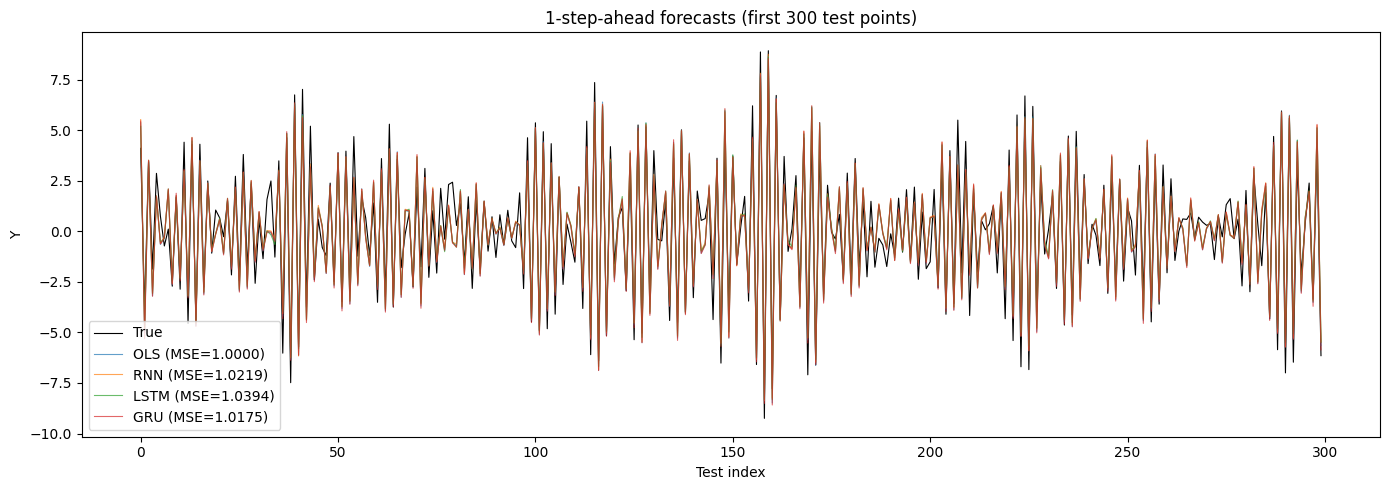

In [11]:
ols_results = pd.read_csv('saved_data/ols_results.csv')

n_show = 300
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(n_show), y_test[:n_show], linewidth=0.8, color='black', label='True')
ax.plot(range(n_show), ols_results['y_pred_ols'].to_numpy()[:n_show],
        linewidth=0.8, alpha=0.7, label=f'OLS (MSE={ols_mse:.4f})')
for rnn_type, preds in test_preds.items():
    ax.plot(range(n_show), preds[:n_show],
            linewidth=0.8, alpha=0.7, label=f'{rnn_type} (MSE={test_mses[rnn_type]:.4f})')
ax.set_xlabel('Test index')
ax.set_ylabel('Y')
ax.set_title(f'1-step-ahead forecasts (first {n_show} test points)')
ax.legend()
plt.tight_layout()
plt.show()

### Residual distributions

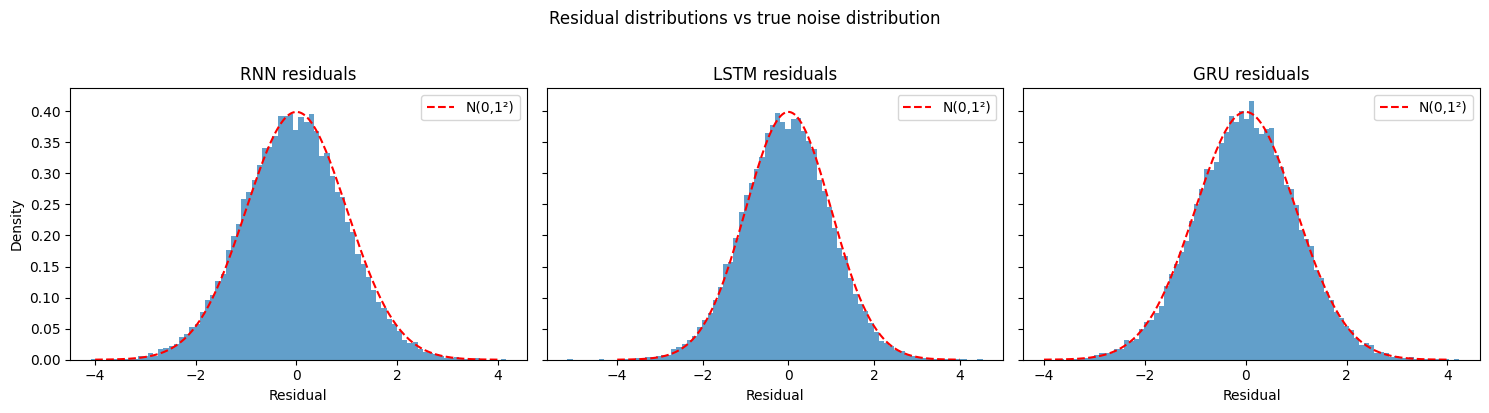

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

xs = np.linspace(-4 * SIGMA, 4 * SIGMA, 200)
true_density = (1 / (SIGMA * np.sqrt(2 * np.pi))) * np.exp(-xs**2 / (2 * SIGMA**2))

for ax, rnn_type in zip(axes, rnn_types):
    resid = y_test - test_preds[rnn_type]
    ax.hist(resid, bins=80, density=True, alpha=0.7)
    ax.plot(xs, true_density, 'r--', linewidth=1.5, label=f'N(0,{SIGMA}²)')
    ax.set_title(f'{rnn_type} residuals')
    ax.set_xlabel('Residual')
    ax.legend()

axes[0].set_ylabel('Density')
plt.suptitle('Residual distributions vs true noise distribution', y=1.02)
plt.tight_layout()
plt.show()

### Weight inspection

For the simple RNN, the recurrent structure is close to the AR linear form.
We can extract the learned weights and see how they relate to the true alphas.

For LSTM/GRU this is less direct due to gating, but we can still inspect the effective
linear mapping from the last hidden state to the output.

In [13]:
for rnn_type, model in models.items():
    print(f'\n=== {rnn_type} ===')
    print(f'True alphas: {true_alphas}')

    fc_weight = model.fc.weight.detach().cpu().numpy().flatten()
    fc_bias = model.fc.bias.detach().cpu().numpy().flatten()
    print(f'Output layer weight shape: {model.fc.weight.shape}')
    print(f'Output layer bias: {fc_bias}')

    for name, param in model.rnn.named_parameters():
        print(f'  {name}: shape={param.shape}')


=== RNN ===
True alphas: [-0.44775626  0.78521643 -0.21437406 -0.48722836  0.23731253]
Output layer weight shape: torch.Size([1, 10])
Output layer bias: [0.13933983]
  weight_ih_l0: shape=torch.Size([10, 1])
  weight_hh_l0: shape=torch.Size([10, 10])
  bias_ih_l0: shape=torch.Size([10])
  bias_hh_l0: shape=torch.Size([10])

=== LSTM ===
True alphas: [-0.44775626  0.78521643 -0.21437406 -0.48722836  0.23731253]
Output layer weight shape: torch.Size([1, 10])
Output layer bias: [-1.1204927]
  weight_ih_l0: shape=torch.Size([40, 1])
  weight_hh_l0: shape=torch.Size([40, 10])
  bias_ih_l0: shape=torch.Size([40])
  bias_hh_l0: shape=torch.Size([40])

=== GRU ===
True alphas: [-0.44775626  0.78521643 -0.21437406 -0.48722836  0.23731253]
Output layer weight shape: torch.Size([1, 10])
Output layer bias: [-0.08547767]
  weight_ih_l0: shape=torch.Size([30, 1])
  weight_hh_l0: shape=torch.Size([30, 10])
  bias_ih_l0: shape=torch.Size([30])
  bias_hh_l0: shape=torch.Size([30])
